# Sales Data Analysis Project
**By Kanwal Kiani**  
This project analyzes sales data from a superstore to understand sales trends, top products, category performance, and profitability.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("SuperStoreOrders.csv")
df.head()


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Data Overview

We first check the dataset structure, column names, data types, and basic statistics.


In [29]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


## Data Cleaning

- Convert date columns to datetime
- Convert numeric columns from text to numbers
- Remove missing or duplicate values

In [30]:
# Strip column spaces
df.columns = df.columns.str.strip()

# Convert order_date
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')

# Convert Sales and Profit to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

# Drop missing or duplicate rows
df = df.dropna(subset=['sales', 'profit', 'order_date'])
df = df.drop_duplicates()

## Total Sales
Calculate total sales in the dataset.

In [31]:
total_sales = df['sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 3075011.0


## Sales by Category
We analyze total sales for each product category and visualize it.

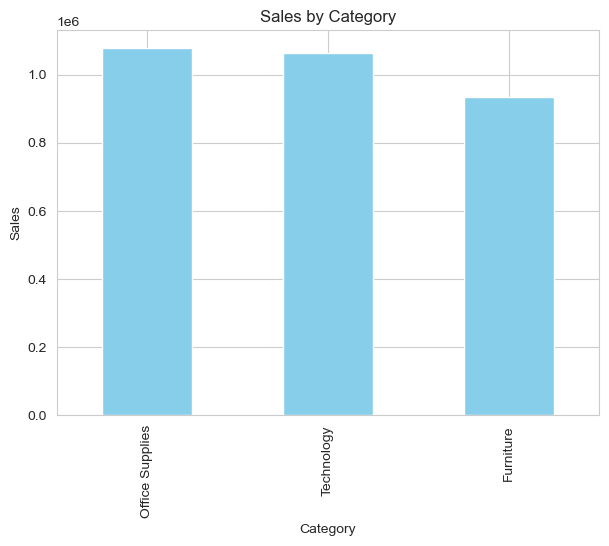

In [32]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', color='skyblue', figsize=(7,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

## Monthly Sales Trend
Analyze how sales change month to month.

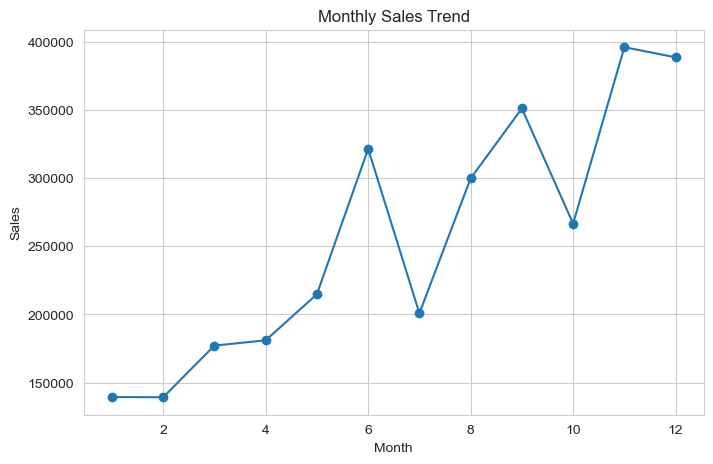

In [33]:
monthly_sales = df.groupby(df['order_date'].dt.month)['sales'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Sales by Region
Compare sales across different regions.

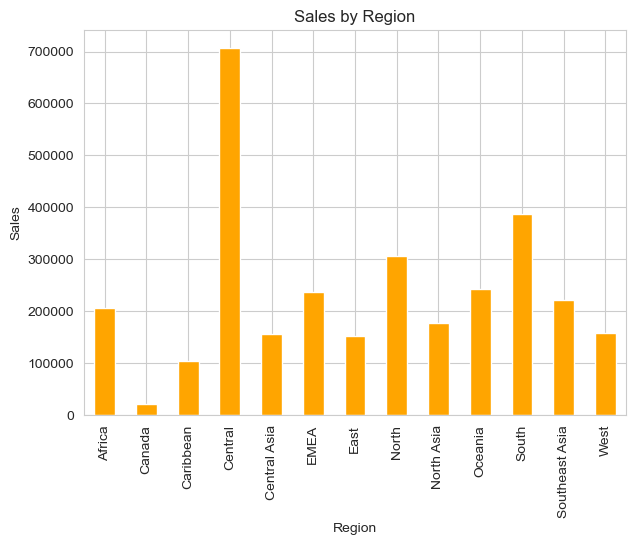

In [34]:
region_sales = df.groupby('region')['sales'].sum()

region_sales.plot(kind='bar', color='orange', figsize=(7,5))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

## Top 10 Products
Identify the top 10 products by sales.

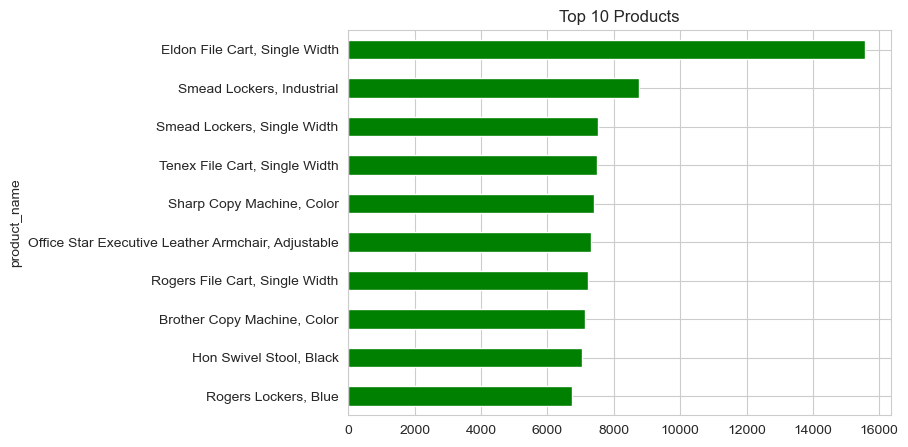

In [36]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', color='green', figsize=(7,5))
plt.title("Top 10 Products")
plt.gca().invert_yaxis()
plt.show()

## Profit by Category
Check which categories are most profitable.

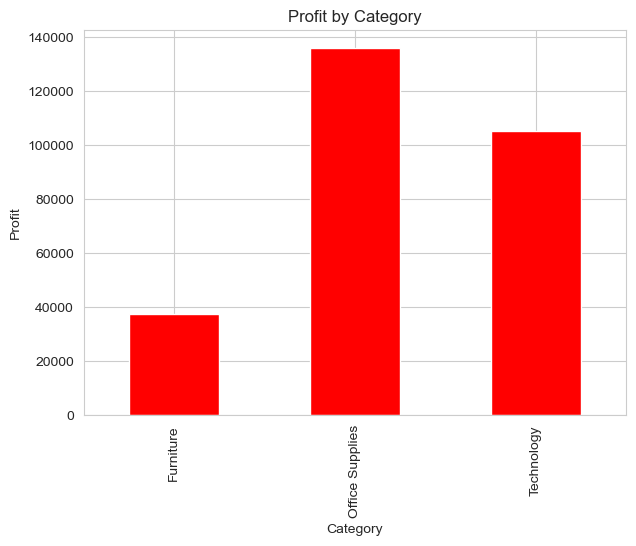

In [37]:
profit = df.groupby('category')['profit'].sum()

profit.plot(kind='bar', color='red', figsize=(7,5))
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## Insights

- Technology category generated the highest sales.
- Sales increased towards the end of the year.
- A few products contributed most of the revenue.
- Some categories had high sales but low profit.